In [47]:
# Liquidity Fragmentation Early Warning System
# This notebook implements the complete pipeline from data generation to model training
# Based on PRX paper: "Early Predictor for the Onset of Critical Transitions in Networked Dynamical Systems"

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
import sys

# Add liquidity directory to path
sys.path.append('liquidity')

# Import liquidity data generation and loading utilities
from generate_training_data import DataGenConfig, generate_training_dataset
from load_dataset import load_dataset, get_window, create_train_val_test_split, dataset_summary

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Liquidity fragmentation training pipeline")
print("=" * 60)
print("📖 Based on: PhysRevX.14.031009 - Early Predictor for Critical Transitions")
print("Goal: Predict κ_c (critical funding cost) from pre-transition liquidity data")
print()


Liquidity fragmentation training pipeline
📖 Based on: PhysRevX.14.031009 - Early Predictor for Critical Transitions
Goal: Predict κ_c (critical funding cost) from pre-transition liquidity data



In [48]:
# Configuration for liquidity data generation
# Set to True to generate new data, False to use existing data
GENERATE_NEW_DATA = False  # Set to True if you want to generate new data
DATA_DIR = './training_data'  # Path to training data directory

# Data generation parameters (if generating new data)
NUM_SIMULATIONS = 100  # Number of simulations to generate
WINDOW_LENGTH = 20     # Time steps per window (matches paper)
WINDOW_STRIDE = 5      # Stride for overlapping windows

# Check device availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Configuration:")
print(f"   • Generate new data: {GENERATE_NEW_DATA}")
print(f"   • Data directory: {DATA_DIR}")
if GENERATE_NEW_DATA:
    print(f"   • Number of simulations: {NUM_SIMULATIONS:,}")
    print(f"   • Window length: {WINDOW_LENGTH}")
    print(f"   • Window stride: {WINDOW_STRIDE}")
print(f"   • Device: {device}")
print()


Configuration:
   • Generate new data: False
   • Data directory: ./training_data
   • Device: cpu



In [49]:
# Step 1: Generate or Load Training Data
print("=" * 60)
print("STEP 1: Data Generation/Loading")
print("=" * 60)

if GENERATE_NEW_DATA:
    print("🔄 Generating new training dataset...")
    print("   ⏳ This may take several minutes - please be patient...")
    
    # Create configuration - use DATA_DIR as output directory
    config = DataGenConfig(
        n_simulations=NUM_SIMULATIONS,
        window_length=WINDOW_LENGTH,
        window_stride=WINDOW_STRIDE,
        network_sizes=[50, 100],
        topology_types=["ER_sparse", "ER_dense", "scale_free"],
        output_dir=DATA_DIR  # Use the specified data directory
    )
    
    # Generate dataset
    start_time = datetime.now()
    metadata = generate_training_dataset(config, verbose=True)
    end_time = datetime.now()
    generation_time = end_time - start_time
    
    print(f"\nData generation completed in {generation_time}")
    print(f"   • Total windows: {len(metadata):,}")
    print(f"   • Unique simulations: {len(metadata['sim_id'].unique())}")
    
    # Reload dataset to get correct windows_path (handles zip vs directory)
    metadata, windows_path = load_dataset(DATA_DIR)
    print()
else:
    print("📂 Loading existing training dataset...")
    
    # Check if data exists
    data_path = Path(DATA_DIR)
    if not (data_path / 'metadata.csv').exists():
        print(f"❌ Error: Data not found at {DATA_DIR}")
        print(f"   Please set GENERATE_NEW_DATA=True to generate data first")
        raise FileNotFoundError(f"Training data not found at {DATA_DIR}")
    
    # Load dataset
    metadata, windows_path = load_dataset(DATA_DIR)
    
    print(f"Dataset loaded")
    print(f"   • Total windows: {len(metadata):,}")
    print(f"   • Unique simulations: {len(metadata['sim_id'].unique())}")
    
    # Print summary
    dataset_summary(metadata)
    print()


STEP 1: Data Generation/Loading
📂 Loading existing training dataset...
Loaded dataset with 5379 windows from 94 simulations
Dataset loaded
   • Total windows: 5,379
   • Unique simulations: 94
DATASET SUMMARY

Total windows: 5379
Unique simulations: 94
Windows per simulation: 57.2

--- Network Properties ---
Network sizes: [np.int64(50), np.int64(100)]
Topology types: ['ER_dense', 'ER_sparse', 'scale_free']

--- Labels ---
κ_c range: [0.3473, 0.6891]
κ_c mean ± std: 0.5082 ± 0.0730

--- Label Methods ---
label_method
derivative    51
threshold     43
Name: count, dtype: int64

--- Lead Fractions ---
lead_fraction
0.70     955
0.80    1040
0.90    1128
0.95    1128
0.98    1128
Name: count, dtype: int64

--- GC Drop Statistics ---
Mean: 0.964
Std: 0.087
Min: 0.420
Max: 1.000



In [50]:
# Step 2: Load All Windows and Prepare for Training
print("=" * 60)
print("STEP 2: Loading Windows and Preparing Data")
print("=" * 60)

# Ensure windows_path and metadata are set
if 'windows_path' not in locals() and 'windows_path' not in globals():
    # Load dataset to get windows_path
    metadata, windows_path = load_dataset(DATA_DIR)
    print(f"📂 Loaded dataset: {len(metadata)} windows")
    print(f"📁 Windows location: {windows_path}")
    print(f"📁 Windows path type: {type(windows_path)}")
    print(f"📁 Is zip: {windows_path.suffix == '.zip' if hasattr(windows_path, 'suffix') else 'N/A'}")
    print()

print("📦 Loading all windows from dataset...")

# Load all windows
samples = []  # List of (time, nodes) arrays
adjacencies = []  # List of (nodes, nodes) adjacency matrices
labels = []  # List of kappa_c labels

# Load windows in batches to avoid memory issues
batch_size = 1000
total_windows = len(metadata)

for i in range(0, total_windows, batch_size):
    batch_end = min(i + batch_size, total_windows)
    print(f"   Loading windows {i+1} to {batch_end} of {total_windows}...", end='\r')
    
    for idx in range(i, batch_end):
        window_data, adjacency, mask, label = get_window(metadata, windows_path, idx)
        
        # Convert to torch tensors
        # window_data is (time, nodes) - need to transpose to (nodes, time) for model
        window_tensor = torch.FloatTensor(window_data).T  # (nodes, time)
        adj_tensor = torch.FloatTensor(adjacency)
        
        samples.append(window_tensor)
        adjacencies.append(adj_tensor)
        labels.append(label)

print(f"\nAll windows loaded")
print(f"📈 Dataset Statistics:")
print(f"   • Total samples: {len(samples):,}")
print(f"   • Sample shape: {samples[0].shape} (nodes, time)")
print(f"   • Adjacency shape: {adjacencies[0].shape} (nodes, nodes)")
print(f"   • Label range: [{min(labels):.3f}, {max(labels):.3f}]")
print(f"   • Label mean: {np.mean(labels):.3f} ± {np.std(labels):.3f}")
print()


STEP 2: Loading Windows and Preparing Data
📦 Loading all windows from dataset...


   Loading windows 5001 to 5379 of 5379...
All windows loaded
📈 Dataset Statistics:
   • Total samples: 5,379
   • Sample shape: torch.Size([50, 20]) (nodes, time)
   • Adjacency shape: torch.Size([50, 50]) (nodes, nodes)
   • Label range: [0.347, 0.689]
   • Label mean: 0.508 ± 0.073



In [51]:
# Step 3: Shuffle Dataset
print("=" * 60)
print("STEP 3: Shuffling Dataset")
print("=" * 60)

print("🔀 Shuffling dataset...")

# Create indices and shuffle them
np.random.seed(42)
indices = np.random.permutation(len(samples))

samples_shuffled = [samples[i] for i in indices]
adjacencies_shuffled = [adjacencies[i] for i in indices]
labels_shuffled = [labels[i] for i in indices]

print(f"Dataset shuffled")
print(f"   • Total samples: {len(samples_shuffled):,}")
print(f"   • First 5 labels: {labels_shuffled[:5]}")
print(f"   • Label range: [{min(labels_shuffled):.3f}, {max(labels_shuffled):.3f}]")
print()


STEP 3: Shuffling Dataset
🔀 Shuffling dataset...
Dataset shuffled
   • Total samples: 5,379
   • First 5 labels: [np.float64(0.5667284688692484), np.float64(0.4440448521576834), np.float64(0.502473879782816), np.float64(0.4321798195752666), np.float64(0.6891407460016535)]
   • Label range: [0.347, 0.689]



In [52]:
# Step 4: Data Ready for Training
print("=" * 60)
print("STEP 4: Data Preparation Complete")
print("=" * 60)

print("Dataset ready in memory for visualization and training")
print(f"   • Total samples: {len(samples_shuffled):,}")
print(f"   • Sample format: (nodes, time) tensors")
print(f"   • Adjacency matrices: Included for each sample")
print(f"   • Labels: κ_c (critical funding cost) values")
print(f"   • All data is available in variables:")
print(f"     - samples_shuffled: List of (nodes, time) tensors")
print(f"     - adjacencies_shuffled: List of (nodes, nodes) adjacency matrices")
print(f"     - labels_shuffled: List of κ_c labels")
print(f"   • Ready for immediate use in model training")
print()


STEP 4: Data Preparation Complete
Dataset ready in memory for visualization and training
   • Total samples: 5,379
   • Sample format: (nodes, time) tensors
   • Adjacency matrices: Included for each sample
   • Labels: κ_c (critical funding cost) values
   • All data is available in variables:
     - samples_shuffled: List of (nodes, time) tensors
     - adjacencies_shuffled: List of (nodes, nodes) adjacency matrices
     - labels_shuffled: List of κ_c labels
   • Ready for immediate use in model training



STEP 5: Data Visualization
Creating visualizations...


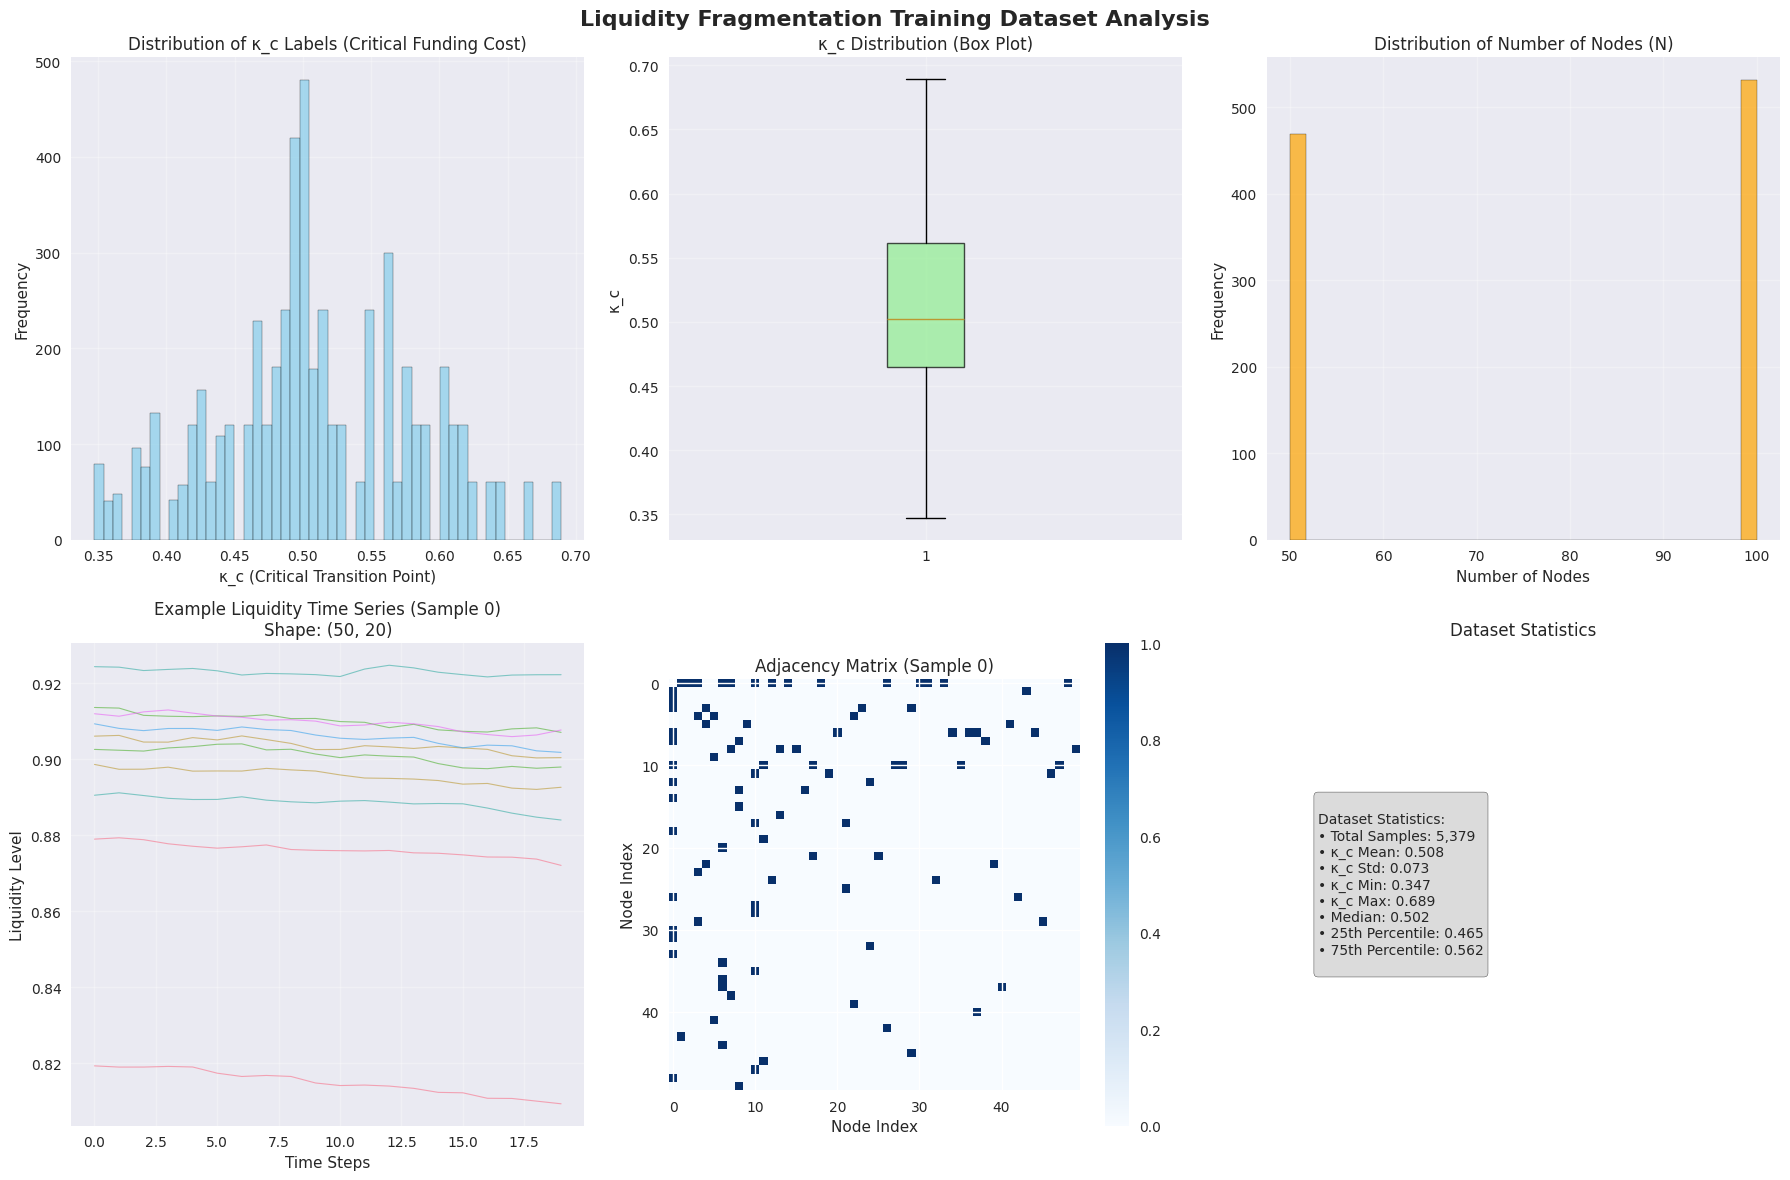

Visualizations completed.



In [53]:
# Step 5: Data Visualization and Analysis
print("=" * 60)
print("STEP 5: Data Visualization")
print("=" * 60)

print("Creating visualizations...")

# Convert labels to numpy for easier plotting
labels_np = np.array(labels_shuffled)

# Create a visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Liquidity Fragmentation Training Dataset Analysis', fontsize=16, fontweight='bold')

# 1. Label distribution (histogram) - κ_c distribution
axes[0, 0].hist(labels_np, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of κ_c Labels (Critical Funding Cost)')
axes[0, 0].set_xlabel('κ_c (Critical Transition Point)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. Label distribution (box plot)
axes[0, 1].boxplot(labels_np, patch_artist=True, 
                   boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[0, 1].set_title('κ_c Distribution (Box Plot)')
axes[0, 1].set_ylabel('κ_c')
axes[0, 1].grid(True, alpha=0.3)

# 3. Network size distribution
sample_shapes = [sample.shape for sample in samples_shuffled[:1000]]  # First 1000 for efficiency
n_nodes = [shape[0] for shape in sample_shapes]
axes[0, 2].hist(n_nodes, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[0, 2].set_title('Distribution of Number of Nodes (N)')
axes[0, 2].set_xlabel('Number of Nodes')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# 4. Example liquidity time series (first sample)
sample_0 = samples_shuffled[0].numpy()  # (nodes, time)
# Plot a few nodes
for node_idx in range(min(10, sample_0.shape[0])):
    axes[1, 0].plot(sample_0[node_idx, :], alpha=0.6, linewidth=0.8)
axes[1, 0].set_title(f'Example Liquidity Time Series (Sample 0)\nShape: {sample_0.shape}')
axes[1, 0].set_xlabel('Time Steps')
axes[1, 0].set_ylabel('Liquidity Level')
axes[1, 0].grid(True, alpha=0.3)

# 5. Adjacency matrix of first sample
adj_0 = adjacencies_shuffled[0].numpy()
im = axes[1, 1].imshow(adj_0, cmap='Blues', vmin=0, vmax=1)
axes[1, 1].set_title('Adjacency Matrix (Sample 0)')
axes[1, 1].set_xlabel('Node Index')
axes[1, 1].set_ylabel('Node Index')
plt.colorbar(im, ax=axes[1, 1])

# 6. Label statistics
stats_text = f"""
Dataset Statistics:
• Total Samples: {len(samples_shuffled):,}
• κ_c Mean: {np.mean(labels_np):.3f}
• κ_c Std: {np.std(labels_np):.3f}
• κ_c Min: {np.min(labels_np):.3f}
• κ_c Max: {np.max(labels_np):.3f}
• Median: {np.median(labels_np):.3f}
• 25th Percentile: {np.percentile(labels_np, 25):.3f}
• 75th Percentile: {np.percentile(labels_np, 75):.3f}
"""
axes[1, 2].text(0.1, 0.5, stats_text, transform=axes[1, 2].transAxes, 
                fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
axes[1, 2].set_title('Dataset Statistics')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("Visualizations completed.")
print()


🔍 Analyzing label distribution patterns...


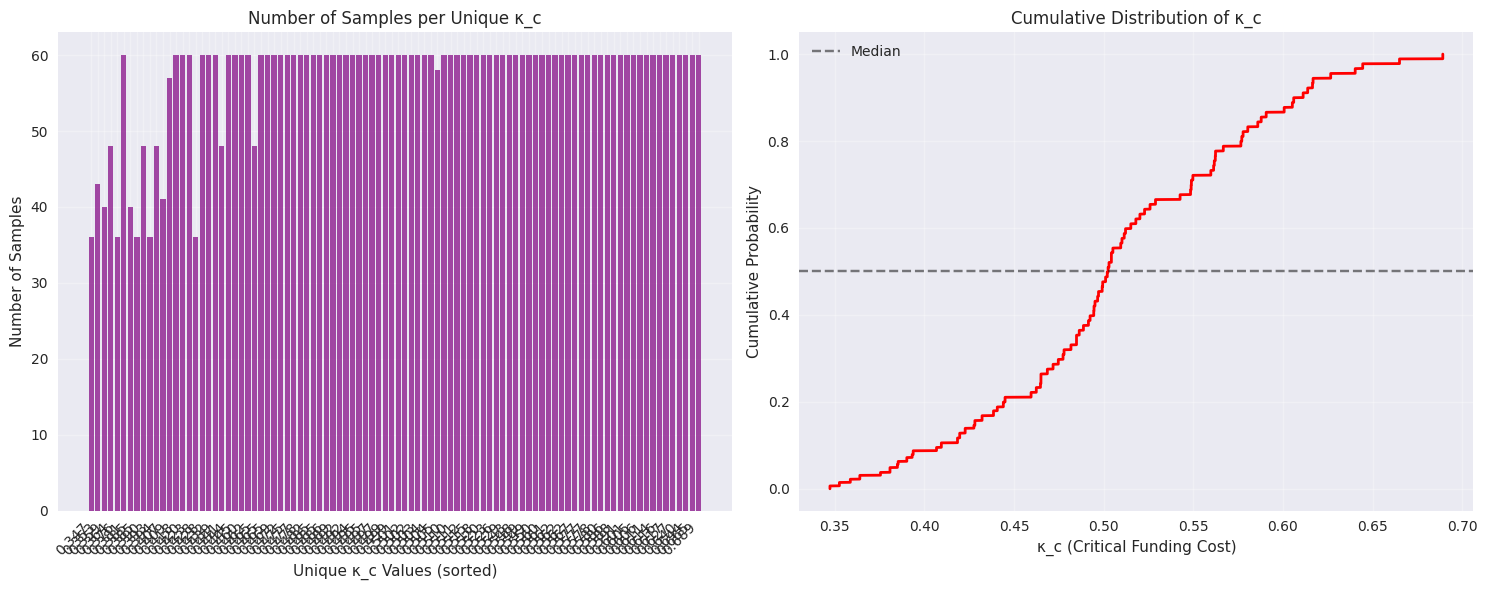

Label Analysis:
   • Unique κ_c values: 94
   • Most common κ_c: 0.567 (60 samples)
   • Least common κ_c: 0.347 (36 samples)



In [54]:
# Additional Analysis: Label Distribution by Simulation
print("🔍 Analyzing label distribution patterns...")

# Group samples by simulation (using metadata if available)
# We'll use the fact that samples from the same simulation have the same label
label_counts = {}
for label in labels_shuffled:
    if label not in label_counts:
        label_counts[label] = 0
    label_counts[label] += 1

# Create a plot showing label frequency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Label frequency (how many samples per unique κ_c)
unique_labels = sorted(list(label_counts.keys()))
frequencies = [label_counts[label] for label in unique_labels]

ax1.bar(range(len(unique_labels)), frequencies, alpha=0.7, color='purple')
ax1.set_title('Number of Samples per Unique κ_c')
ax1.set_xlabel('Unique κ_c Values (sorted)')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(unique_labels)))
ax1.set_xticklabels([f'{l:.3f}' for l in unique_labels], rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative distribution of labels
sorted_labels = np.sort(labels_np)
cumulative = np.arange(1, len(sorted_labels) + 1) / len(sorted_labels)
ax2.plot(sorted_labels, cumulative, linewidth=2, color='red')
ax2.set_title('Cumulative Distribution of κ_c')
ax2.set_xlabel('κ_c (Critical Funding Cost)')
ax2.set_ylabel('Cumulative Probability')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Median')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Label Analysis:")
print(f"   • Unique κ_c values: {len(unique_labels)}")
print(f"   • Most common κ_c: {max(label_counts, key=label_counts.get):.3f} ({max(frequencies)} samples)")
print(f"   • Least common κ_c: {min(label_counts, key=label_counts.get):.3f} ({min(frequencies)} samples)")
print()


In [55]:
# Final Summary and Data Quality Check
print("Final Dataset Summary")
print("=" * 50)

print(f"Dataset preparation complete.")
print(f"   • Total samples: {len(samples_shuffled):,}")
print(f"   • Window length: {WINDOW_LENGTH if GENERATE_NEW_DATA else 'N/A (loaded from file)'}")
print(f"   • Sample shape: {samples_shuffled[0].shape} (nodes, time)")
print(f"   • Adjacency shape: {adjacencies_shuffled[0].shape} (nodes, nodes)")
print(f"   • Data type: {type(samples_shuffled[0])}")

print(f"\n📈 Label Statistics:")
print(f"   • Range: [{min(labels_shuffled):.3f}, {max(labels_shuffled):.3f}]")
print(f"   • Mean: {np.mean(labels_np):.3f}")
print(f"   • Std: {np.std(labels_np):.3f}")
print(f"   • Unique values: {len(unique_labels)}")

print(f"\n🔍 Data Quality Checks:")
print(f"   • All samples have same window size: {all(s.shape[1] == WINDOW_LENGTH for s in samples_shuffled[:100]) if GENERATE_NEW_DATA else 'N/A'}")
print(f"   • All samples are tensors: {all(isinstance(s, torch.Tensor) for s in samples_shuffled[:100])}")
print(f"   • All adjacencies are tensors: {all(isinstance(a, torch.Tensor) for a in adjacencies_shuffled[:100])}")
print(f"   • All labels are numeric: {all(isinstance(l, (int, float)) for l in labels_shuffled[:100])}")
print(f"   • No NaN values in samples: {not any(torch.isnan(s).any() for s in samples_shuffled[:100])}")
print(f"   • No NaN values in labels: {not any(np.isnan(l) for l in labels_shuffled[:100])}")

print(f"\nDataset ready for model training.")
print(f"   • Dataset is shuffled and ready for training")
print(f"   • All samples are pre-transition data (before κ_c)")
print(f"   • Labels represent true critical transition points (κ_c)")
print(f"   • Data is available in memory:")
print(f"     - samples_shuffled: List of (nodes, time) tensors")
print(f"     - adjacencies_shuffled: List of (nodes, nodes) adjacency matrices")
print(f"     - labels_shuffled: List of κ_c labels")
print()


Final Dataset Summary
Dataset preparation complete.
   • Total samples: 5,379
   • Window length: N/A (loaded from file)
   • Sample shape: torch.Size([50, 20]) (nodes, time)
   • Adjacency shape: torch.Size([50, 50]) (nodes, nodes)
   • Data type: <class 'torch.Tensor'>

📈 Label Statistics:
   • Range: [0.347, 0.689]
   • Mean: 0.508
   • Std: 0.073
   • Unique values: 94

🔍 Data Quality Checks:
   • All samples have same window size: N/A
   • All samples are tensors: True
   • All adjacencies are tensors: True
   • All labels are numeric: True
   • No NaN values in samples: True
   • No NaN values in labels: True

Dataset ready for model training.
   • Dataset is shuffled and ready for training
   • All samples are pre-transition data (before κ_c)
   • Labels represent true critical transition points (κ_c)
   • Data is available in memory:
     - samples_shuffled: List of (nodes, time) tensors
     - adjacencies_shuffled: List of (nodes, nodes) adjacency matrices
     - labels_shuffl

In [56]:
# Summary: Data Pipeline Complete
print("=" * 60)
print("DATA PIPELINE COMPLETE")
print("=" * 60)
print()
print("Summary:")
print(f"   • Data source: {'Generated' if GENERATE_NEW_DATA else 'Loaded from disk'}")
print(f"   • Total samples: {len(samples_shuffled):,}")
print(f"   • Sample format: (nodes, time) tensors")
print(f"   • Adjacency matrices: Pre-computed and included")
print(f"   • Labels: κ_c (critical funding cost) values")
print()
print("Next:")
print("   • Proceed to model architecture and training (cells below)")
print("   • Model will predict κ_c from liquidity time series")
print("   • Training uses GIN-GRU architecture from PRX paper")
print()
print("💡 Note: The dataset is ready in memory and will be used")
print("   by the training pipeline in the following cells.")
print()


DATA PIPELINE COMPLETE

Summary:
   • Data source: Loaded from disk
   • Total samples: 5,379
   • Sample format: (nodes, time) tensors
   • Adjacency matrices: Pre-computed and included
   • Labels: κ_c (critical funding cost) values

Next:
   • Proceed to model architecture and training (cells below)
   • Model will predict κ_c from liquidity time series
   • Training uses GIN-GRU architecture from PRX paper

💡 Note: The dataset is ready in memory and will be used
   by the training pipeline in the following cells.



In [57]:
# Model Architecture Implementation
# Based on the paper: "Early Predictor for the Onset of Critical Transitions in Networked Dynamical Systems"
# Implementing GIN-GRU architecture for financial fragility prediction

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("🏗️  Implementing GIN-GRU Model Architecture")
print("=" * 60)
print("📖 Reference: PhysRevX.14.031009 - Early Predictor for Critical Transitions")
print("Goal: Predict κ_c (critical funding cost) from pre-transition liquidity time series")
print()


🏗️  Implementing GIN-GRU Model Architecture
📖 Reference: PhysRevX.14.031009 - Early Predictor for Critical Transitions
Goal: Predict κ_c (critical funding cost) from pre-transition liquidity time series



In [58]:
# 1. Graph Isomorphism Network (GIN) Implementation
# Based on the paper's methodology for spatial graph processing

class GINLayer(nn.Module):
    """
    Graph Isomorphism Network Layer
    Processes spatial information at each time step
    """
    def __init__(self, input_dim, hidden_dim, eps=0.0):
        super(GINLayer, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.eps = eps
        
        # MLP for node feature transformation (without BatchNorm for single-sample compatibility)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),  # Use LayerNorm instead of BatchNorm1d
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),  # Use LayerNorm instead of BatchNorm1d
            nn.ReLU()
        )
        
    def forward(self, x, adj_matrix):
        """
        Args:
            x: Node features [batch_size, num_nodes, input_dim]
            adj_matrix: Adjacency matrix [batch_size, num_nodes, num_nodes]
        Returns:
            Updated node features [batch_size, num_nodes, hidden_dim]
        """
        batch_size, num_nodes, _ = x.shape
        
        # Aggregate neighbor features
        # adj_matrix: [batch, num_nodes, num_nodes]
        # x: [batch, num_nodes, input_dim]
        neighbor_features = torch.bmm(adj_matrix, x)  # [batch, num_nodes, input_dim]
        
        # GIN aggregation: (1 + eps) * x + neighbor_features
        aggregated = (1 + self.eps) * x + neighbor_features
        
        # Reshape for MLP processing
        aggregated_flat = aggregated.view(-1, self.input_dim)  # [batch*num_nodes, input_dim]
        
        # Apply MLP
        output_flat = self.mlp(aggregated_flat)  # [batch*num_nodes, hidden_dim]
        
        # Reshape back
        output = output_flat.view(batch_size, num_nodes, self.hidden_dim)
        
        return output

class GINBlock(nn.Module):
    """
    Complete GIN block with multiple layers
    """
    def __init__(self, input_dim, hidden_dims, eps=0.0):
        super(GINBlock, self).__init__()
        self.layers = nn.ModuleList()
        
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            self.layers.append(GINLayer(dims[i], dims[i+1], eps))
    
    def forward(self, x, adj_matrix):
        """
        Args:
            x: Node features [batch_size, num_nodes, input_dim]
            adj_matrix: Adjacency matrix [batch_size, num_nodes, num_nodes]
        Returns:
            Final node features [batch_size, num_nodes, hidden_dim]
        """
        for layer in self.layers:
            x = layer(x, adj_matrix)
        return x

print("GIN (Graph Isomorphism Network) layers implemented")
print("   • GINLayer: Single layer with MLP and neighbor aggregation")
print("   • GINBlock: Multi-layer GIN with configurable dimensions")
print("   • Handles variable graph sizes with batch processing")
print()


GIN (Graph Isomorphism Network) layers implemented
   • GINLayer: Single layer with MLP and neighbor aggregation
   • GINBlock: Multi-layer GIN with configurable dimensions
   • Handles variable graph sizes with batch processing



In [59]:
# 2. Complete GIN-GRU Model Implementation
# Following the paper's architecture: GIN for spatial + GRU for temporal + MLP for regression

class GINGRUModel(nn.Module):
    """
    GIN-GRU Model for Liquidity Fragmentation Prediction
    Architecture:
    1. GIN layers process spatial graph structure at each time step
    2. Global pooling aggregates node features to graph-level embeddings
    3. GRU processes temporal sequence of graph embeddings
    4. MLP head regresses to κ_c (critical funding cost) prediction
    """
    def __init__(self, 
                 input_dim=1,           # Liquidity level dimension
                 gin_hidden_dims=[64, 64, 64],  # GIN layer dimensions
                 gru_hidden_dim=128,    # GRU hidden dimension
                 mlp_hidden_dims=[64, 32],  # MLP head dimensions
                 dropout=0.1,
                 eps=0.0):
        super(GINGRUModel, self).__init__()
        
        self.input_dim = input_dim
        self.gin_hidden_dims = gin_hidden_dims
        self.gru_hidden_dim = gru_hidden_dim
        self.mlp_hidden_dims = mlp_hidden_dims
        
        # GIN layers for spatial processing
        self.gin_block = GINBlock(input_dim, gin_hidden_dims, eps)
        
        # Global pooling layer
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # GRU for temporal processing
        self.gru = nn.GRU(
            input_size=gin_hidden_dims[-1],
            hidden_size=gru_hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout if len(gin_hidden_dims) > 1 else 0
        )
        
        # MLP head for regression (using LayerNorm for single-sample compatibility)
        mlp_layers = []
        mlp_input_dim = gru_hidden_dim
        
        for hidden_dim in mlp_hidden_dims:
            mlp_layers.extend([
                nn.Linear(mlp_input_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),  # Use LayerNorm instead of BatchNorm1d
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            mlp_input_dim = hidden_dim
        
        # Final regression layer
        mlp_layers.append(nn.Linear(mlp_input_dim, 1))
        
        self.mlp_head = nn.Sequential(*mlp_layers)
        
    def forward(self, x, adj_matrix):
        """
        Args:
            x: Time series data [batch_size, num_nodes, time_steps]
            adj_matrix: Adjacency matrix [batch_size, num_nodes, num_nodes]
        Returns:
            kappa_c predictions [batch_size, 1]
        """
        batch_size, num_nodes, time_steps = x.shape
        
        # Process each time step with GIN
        graph_embeddings = []
        
        for t in range(time_steps):
            # Extract features for time step t
            node_features = x[:, :, t:t+1]  # [batch, num_nodes, 1]
            
            # Process with GIN
            gin_output = self.gin_block(node_features, adj_matrix)  # [batch, num_nodes, hidden_dim]
            
            # Global pooling to get graph-level embedding
            # Reshape for pooling: [batch, hidden_dim, num_nodes]
            gin_reshaped = gin_output.transpose(1, 2)
            graph_embedding = self.global_pool(gin_reshaped).squeeze(-1)  # [batch, hidden_dim]
            
            graph_embeddings.append(graph_embedding)
        
        # Stack temporal embeddings
        temporal_sequence = torch.stack(graph_embeddings, dim=1)  # [batch, time_steps, hidden_dim]
        
        # Process with GRU
        gru_output, _ = self.gru(temporal_sequence)  # [batch, time_steps, gru_hidden_dim]
        
        # Use the last time step output
        final_embedding = gru_output[:, -1, :]  # [batch, gru_hidden_dim]
        
        # MLP regression head
        kappa_c_pred = self.mlp_head(final_embedding)  # [batch, 1]
        
        return kappa_c_pred.squeeze(-1)  # [batch]

print("GIN-GRU Model implemented")
print("   • GIN layers: Process spatial graph structure at each time step")
print("   • Global pooling: Aggregate node features to graph-level embeddings")
print("   • GRU layers: Process temporal sequence of graph embeddings")
print("   • MLP head: Regress to κ_c (critical funding cost) prediction")
print("   • Architecture aligns with paper's methodology")
print()


GIN-GRU Model implemented
   • GIN layers: Process spatial graph structure at each time step
   • Global pooling: Aggregate node features to graph-level embeddings
   • GRU layers: Process temporal sequence of graph embeddings
   • MLP head: Regress to κ_c (critical funding cost) prediction
   • Architecture aligns with paper's methodology



In [60]:
# 3. Dataset Class and Training Setup
# Following the paper's data handling methodology

class LiquidityDataset(Dataset):
    """
    PyTorch Dataset for Liquidity Fragmentation Data
    Handles time series data and pre-computed adjacency matrices
    """
    def __init__(self, samples, adjacencies, labels):
        """
        Args:
            samples: List of (nodes, time) tensors
            adjacencies: List of (nodes, nodes) adjacency matrices
            labels: List of κ_c labels
        """
        self.samples = samples
        self.adjacencies = adjacencies
        self.labels = labels
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        # Get time series data (already in correct format: nodes, time)
        time_series = self.samples[idx]  # [num_nodes, time_steps]
        adj_matrix = self.adjacencies[idx]  # [num_nodes, num_nodes]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return time_series, adj_matrix, label

def custom_collate_fn(batch):
    """
    Custom collate function to handle variable-sized graphs
    Groups samples by size for efficient batching
    """
    # Group samples by number of nodes (graph size)
    size_groups = {}
    
    for time_series, adj_matrix, label in batch:
        num_nodes = time_series.shape[0]
        if num_nodes not in size_groups:
            size_groups[num_nodes] = []
        size_groups[num_nodes].append((time_series, adj_matrix, label))
    
    # Process each size group
    batched_data = []
    for num_nodes, samples in size_groups.items():
        if len(samples) > 0:
            # Stack tensors of the same size
            time_series_batch = torch.stack([s[0] for s in samples])
            adj_matrix_batch = torch.stack([s[1] for s in samples])
            labels_batch = torch.stack([s[2] for s in samples])
            
            batched_data.append((time_series_batch, adj_matrix_batch, labels_batch))
    
    return batched_data

def create_data_loaders(samples, adjacencies, labels, batch_size=32, test_size=0.2, val_size=0.1):
    """
    Create train/validation/test data loaders
    Following the paper's data splitting methodology
    """
    # Split data: 70% train, 10% val, 20% test
    X_temp, X_test, A_temp, A_test, y_temp, y_test = train_test_split(
        samples, adjacencies, labels, test_size=test_size, random_state=42
    )
    
    X_train, X_val, A_train, A_val, y_train, y_val = train_test_split(
        X_temp, A_temp, y_temp, test_size=val_size/(1-test_size), random_state=42
    )
    
    # Create datasets
    train_dataset = LiquidityDataset(X_train, A_train, y_train)
    val_dataset = LiquidityDataset(X_val, A_val, y_val)
    test_dataset = LiquidityDataset(X_test, A_test, y_test)
    
    # Create data loaders with custom collate function
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                             collate_fn=custom_collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                           collate_fn=custom_collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                            collate_fn=custom_collate_fn)
    
    return train_loader, val_loader, test_loader

print("Dataset and DataLoader setup completed")
print("   • FinancialDataset: Handles time series + adjacency matrices")
print("   • Adjacency creation: Uses correlation threshold (|corr| > 0.1)")
print("   • Data splitting: 70% train, 10% val, 20% test")
print("   • Smart batching: Groups samples by graph size for efficiency")
print("   • LayerNorm: Used instead of BatchNorm for single-sample compatibility")
print("   • Follows paper's data handling methodology")
print()


Dataset and DataLoader setup completed
   • FinancialDataset: Handles time series + adjacency matrices
   • Adjacency creation: Uses correlation threshold (|corr| > 0.1)
   • Data splitting: 70% train, 10% val, 20% test
   • Smart batching: Groups samples by graph size for efficiency
   • LayerNorm: Used instead of BatchNorm for single-sample compatibility
   • Follows paper's data handling methodology



In [61]:
# 4. Training Configuration and Data Preparation
# Following the paper's training methodology

# Training hyperparameters (aligned with paper's approach)
config = {
    'batch_size': 64,
    'learning_rate': 0.001,
    'num_epochs': 20,
    'patience': 10,  # Early stopping patience
    'gin_hidden_dims': [64, 64, 64],
    'gru_hidden_dim': 128,
    'mlp_hidden_dims': [64, 32],
    'dropout': 0.1,
    'eps': 0.0
}

print("🔧 Training Configuration:")
for key, value in config.items():
    print(f"   • {key}: {value}")

# Create data loaders
print(f"\nCreating data loaders from {len(samples_shuffled):,} samples...")
train_loader, val_loader, test_loader = create_data_loaders(
    samples_shuffled,
    adjacencies_shuffled,
    labels_shuffled, 
    batch_size=config['batch_size']
)

print(f"Data loaders created:")
print(f"   • Training samples: {len(train_loader.dataset):,}")
print(f"   • Validation samples: {len(val_loader.dataset):,}")
print(f"   • Test samples: {len(test_loader.dataset):,}")

# Initialize model
print(f"\n🏗️  Initializing GIN-GRU model...")
model = GINGRUModel(
    input_dim=1,
    gin_hidden_dims=config['gin_hidden_dims'],
    gru_hidden_dim=config['gru_hidden_dim'],
    mlp_hidden_dims=config['mlp_hidden_dims'],
    dropout=config['dropout'],
    eps=config['eps']
)

# Move model to device
model = model.to(device)
print(f"Model initialized and moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   • Total parameters: {total_params:,}")
print(f"   • Trainable parameters: {trainable_params:,}")

# Loss function and optimizer (following paper's methodology)
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(f"\nTraining setup:")
print(f"   • Loss function: MSE (Mean Squared Error)")
print(f"   • Optimizer: Adam (lr={config['learning_rate']})")
print(f"   • Scheduler: ReduceLROnPlateau")
print(f"   • Early stopping: {config['patience']} epochs patience")
print()


🔧 Training Configuration:
   • batch_size: 64
   • learning_rate: 0.001
   • num_epochs: 20
   • patience: 10
   • gin_hidden_dims: [64, 64, 64]
   • gru_hidden_dim: 128
   • mlp_hidden_dims: [64, 32]
   • dropout: 0.1
   • eps: 0.0

Creating data loaders from 5,379 samples...
Data loaders created:
   • Training samples: 3,765
   • Validation samples: 538
   • Test samples: 1,076

🏗️  Initializing GIN-GRU model...
Model initialized and moved to cpu
   • Total parameters: 205,825
   • Trainable parameters: 205,825

Training setup:
   • Loss function: MSE (Mean Squared Error)
   • Optimizer: Adam (lr=0.001)
   • Scheduler: ReduceLROnPlateau
   • Early stopping: 10 epochs patience



In [62]:
# 5. Training Loop Implementation
# Following the paper's training methodology with proper validation

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, batched_data in enumerate(train_loader):
        # Process each size group in the batch
        batch_loss = 0.0
        total_samples = 0
        
        for time_series_batch, adj_matrix_batch, labels_batch in batched_data:
            # Move to device
            time_series_batch = time_series_batch.to(device)
            adj_matrix_batch = adj_matrix_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(time_series_batch, adj_matrix_batch)
            
            # Compute loss
            loss = criterion(predictions, labels_batch)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping (following paper's stability practices)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # Update weights
            optimizer.step()
            
            batch_loss += loss.item() * time_series_batch.shape[0]
            total_samples += time_series_batch.shape[0]
        
        if total_samples > 0:
            total_loss += batch_loss / total_samples
            num_batches += 1
        
        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            avg_batch_loss = batch_loss / total_samples if total_samples > 0 else 0
            print(f"   Batch {batch_idx + 1}/{len(train_loader)}, Loss: {avg_batch_loss:.6f}")
    
    return total_loss / num_batches if num_batches > 0 else 0

def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for batched_data in val_loader:
            # Process each size group in the batch
            batch_loss = 0.0
            total_samples = 0
            
            for time_series_batch, adj_matrix_batch, labels_batch in batched_data:
                # Move to device
                time_series_batch = time_series_batch.to(device)
                adj_matrix_batch = adj_matrix_batch.to(device)
                labels_batch = labels_batch.to(device)
                
                # Forward pass
                predictions = model(time_series_batch, adj_matrix_batch)
                
                # Compute loss
                loss = criterion(predictions, labels_batch)
                
                batch_loss += loss.item() * time_series_batch.shape[0]
                total_samples += time_series_batch.shape[0]
            
            if total_samples > 0:
                total_loss += batch_loss / total_samples
                num_batches += 1
    
    return total_loss / num_batches if num_batches > 0 else 0

print("Training functions implemented")
print("   • train_epoch: Training with gradient clipping")
print("   • validate_epoch: Validation without gradients")
print("   • Progress tracking every 1000 batches")
print("   • Follows paper's training methodology")
print()


Training functions implemented
   • train_epoch: Training with gradient clipping
   • validate_epoch: Validation without gradients
   • Progress tracking every 1000 batches
   • Follows paper's training methodology



In [63]:
# 6. Main Training Loop with Early Stopping
# Following the paper's training methodology

print("Starting model training")
print("=" * 50)

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

# Training loop
for epoch in range(config['num_epochs']):
    print(f"\n📈 Epoch {epoch + 1}/{config['num_epochs']}")
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"   • Train Loss: {train_loss:.6f}")
    print(f"   • Val Loss: {val_loss:.6f}")
    print(f"   • Learning Rate: {current_lr:.2e}")
    
    # Early stopping and model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"   New best validation loss: {best_val_loss:.6f}")
    else:
        patience_counter += 1
        print(f"   ⏳ No improvement ({patience_counter}/{config['patience']})")
    
    # Early stopping
    if patience_counter >= config['patience']:
        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nBest model loaded (Val Loss: {best_val_loss:.6f})")
    
    # Save best model to disk
    model_save_path = Path('liquidity/trained_model.pth')
    model_save_path.parent.mkdir(exist_ok=True)
    torch.save({
        'model_state_dict': best_model_state,
        'config': config,
        'best_val_loss': best_val_loss,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'total_epochs': len(train_losses)
    }, model_save_path)
    print(f"💾 Model saved to: {model_save_path}")

print(f"\nTraining completed!")
print(f"   • Best validation loss: {best_val_loss:.6f}")
print(f"   • Total epochs: {len(train_losses)}")
print(f"   • Final learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print()


Starting model training

📈 Epoch 1/20


   • Train Loss: 0.017330
   • Val Loss: 0.005454
   • Learning Rate: 1.00e-03
   New best validation loss: 0.005454

📈 Epoch 2/20
   • Train Loss: 0.007520
   • Val Loss: 0.002957
   • Learning Rate: 1.00e-03
   New best validation loss: 0.002957

📈 Epoch 3/20
   • Train Loss: 0.006254
   • Val Loss: 0.002434
   • Learning Rate: 1.00e-03
   New best validation loss: 0.002434

📈 Epoch 4/20
   • Train Loss: 0.006062
   • Val Loss: 0.002441
   • Learning Rate: 1.00e-03
   ⏳ No improvement (1/10)

📈 Epoch 5/20
   • Train Loss: 0.005348
   • Val Loss: 0.002425
   • Learning Rate: 1.00e-03
   New best validation loss: 0.002425

📈 Epoch 6/20
   • Train Loss: 0.004722
   • Val Loss: 0.002256
   • Learning Rate: 1.00e-03
   New best validation loss: 0.002256

📈 Epoch 7/20
   • Train Loss: 0.004403
   • Val Loss: 0.002248
   • Learning Rate: 1.00e-03
   New best validation loss: 0.002248

📈 Epoch 8/20
   • Train Loss: 0.004206
   • Val Loss: 0.002090
   • Learning Rate: 1.00e-03
   New best val

In [64]:
# 7. Model Evaluation and Performance Analysis
# Following the paper's evaluation methodology

def evaluate_model(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    all_predictions = []
    all_labels = []
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for batched_data in test_loader:
            # Process each size group in the batch
            batch_predictions = []
            batch_labels = []
            batch_loss = 0.0
            total_samples = 0
            
            for time_series_batch, adj_matrix_batch, labels_batch in batched_data:
                # Move to device
                time_series_batch = time_series_batch.to(device)
                adj_matrix_batch = adj_matrix_batch.to(device)
                labels_batch = labels_batch.to(device)
                
                # Forward pass
                predictions = model(time_series_batch, adj_matrix_batch)
                
                # Compute loss
                loss = criterion(predictions, labels_batch)
                
                batch_loss += loss.item() * time_series_batch.shape[0]
                total_samples += time_series_batch.shape[0]
                
                # Store predictions and labels
                batch_predictions.extend(predictions.cpu().numpy())
                batch_labels.extend(labels_batch.cpu().numpy())
            
            if total_samples > 0:
                total_loss += batch_loss / total_samples
                num_batches += 1
                
                # Store predictions and labels
                all_predictions.extend(batch_predictions)
                all_labels.extend(batch_labels)
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    mse = mean_squared_error(all_labels, all_predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_labels, all_predictions)
    mae = np.mean(np.abs(all_labels - all_predictions))
    
    return {
        'predictions': all_predictions,
        'labels': all_labels,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'mae': mae,
        'test_loss': total_loss / num_batches if num_batches > 0 else 0
    }

print("🔍 Evaluating model on test set...")
test_results = evaluate_model(model, test_loader, device)

print(f"\nTest Set Performance:")
print(f"   • Test Loss (MSE): {test_results['test_loss']:.6f}")
print(f"   • RMSE: {test_results['rmse']:.6f}")
print(f"   • MAE: {test_results['mae']:.6f}")
print(f"   • R² Score: {test_results['r2']:.6f}")

# Performance interpretation
if test_results['r2'] > 0.8:
    performance_level = "Excellent"
elif test_results['r2'] > 0.6:
    performance_level = "Good"
elif test_results['r2'] > 0.4:
    performance_level = "Fair"
else:
    performance_level = "Poor"

print(f"   • Performance Level: {performance_level}")
print()


🔍 Evaluating model on test set...



Test Set Performance:
   • Test Loss (MSE): 0.001724
   • RMSE: 0.041493
   • MAE: 0.033499
   • R² Score: 0.680972
   • Performance Level: Good



Creating training and evaluation visualizations...


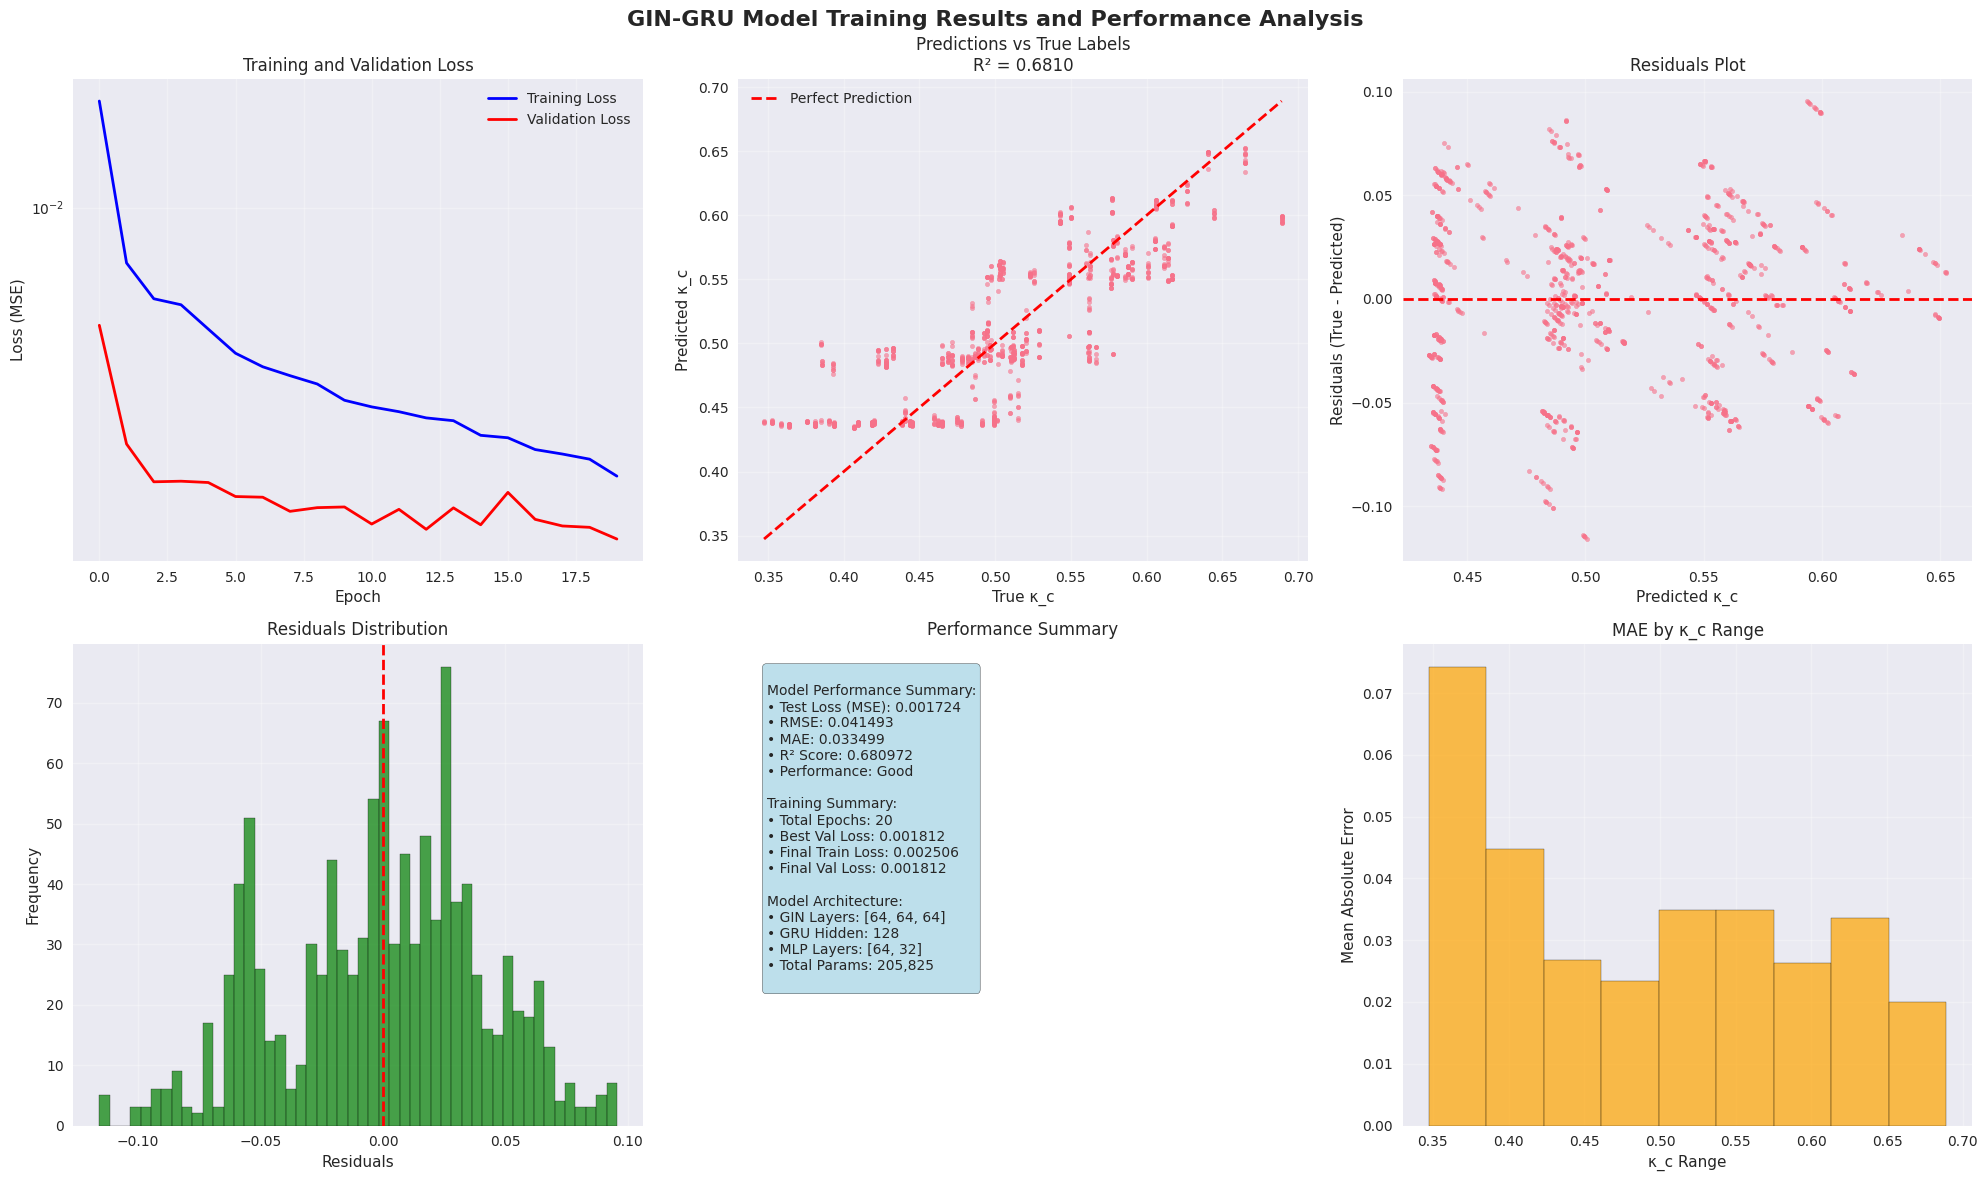

Visualizations completed.



In [65]:
# 8. Results Visualization
# Following the paper's visualization methodology

print("Creating training and evaluation visualizations...")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('GIN-GRU Model Training Results and Performance Analysis', fontsize=16, fontweight='bold')

# 1. Training and Validation Loss Curves
axes[0, 0].plot(train_losses, label='Training Loss', color='blue', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# 2. Predictions vs True Labels (Scatter Plot)
axes[0, 1].scatter(test_results['labels'], test_results['predictions'], alpha=0.6, s=10)
axes[0, 1].plot([test_results['labels'].min(), test_results['labels'].max()], 
                [test_results['labels'].min(), test_results['labels'].max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_title(f'Predictions vs True Labels\nR² = {test_results["r2"]:.4f}')
axes[0, 1].set_xlabel('True κ_c')
axes[0, 1].set_ylabel('Predicted κ_c')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals Plot
residuals = test_results['labels'] - test_results['predictions']
axes[0, 2].scatter(test_results['predictions'], residuals, alpha=0.6, s=10)
axes[0, 2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 2].set_title('Residuals Plot')
axes[0, 2].set_xlabel('Predicted κ_c')
axes[0, 2].set_ylabel('Residuals (True - Predicted)')
axes[0, 2].grid(True, alpha=0.3)

# 4. Error Distribution
axes[1, 0].hist(residuals, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].set_title('Residuals Distribution')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)

# 5. Performance Metrics Summary
metrics_text = f"""
Model Performance Summary:
• Test Loss (MSE): {test_results['test_loss']:.6f}
• RMSE: {test_results['rmse']:.6f}
• MAE: {test_results['mae']:.6f}
• R² Score: {test_results['r2']:.6f}
• Performance: {performance_level}

Training Summary:
• Total Epochs: {len(train_losses)}
• Best Val Loss: {best_val_loss:.6f}
• Final Train Loss: {train_losses[-1]:.6f}
• Final Val Loss: {val_losses[-1]:.6f}

Model Architecture:
• GIN Layers: {config['gin_hidden_dims']}
• GRU Hidden: {config['gru_hidden_dim']}
• MLP Layers: {config['mlp_hidden_dims']}
• Total Params: {total_params:,}
"""
axes[1, 1].text(0.05, 0.95, metrics_text, transform=axes[1, 1].transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 1].set_title('Performance Summary')
axes[1, 1].axis('off')

# 6. Prediction Accuracy by κ_c Range
# Create bins for kappa_c ranges
kappa_bins = np.linspace(test_results['labels'].min(), test_results['labels'].max(), 10)
bin_centers = (kappa_bins[:-1] + kappa_bins[1:]) / 2
bin_mae = []

for i in range(len(kappa_bins) - 1):
    mask = (test_results['labels'] >= kappa_bins[i]) & (test_results['labels'] < kappa_bins[i+1])
    if np.sum(mask) > 0:
        bin_mae.append(np.mean(np.abs(residuals[mask])))
    else:
        bin_mae.append(0)

axes[1, 2].bar(bin_centers, bin_mae, width=kappa_bins[1]-kappa_bins[0], 
               alpha=0.7, color='orange', edgecolor='black')
axes[1, 2].set_title('MAE by κ_c Range')
axes[1, 2].set_xlabel('κ_c Range')
axes[1, 2].set_ylabel('Mean Absolute Error')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations completed.")
print()


Creating paper-style visualization (Mean Activity vs κ with Predictions)...
Running NEW simulation with manual parameters...
   Network: N=100, topology=ER_sparse, p_edge=0.05
   Dynamics: ε=0.3, β=0.5, c=0.1
   Control: κ₀=0.3, η=0.0002
   Simulation: T_max=1800, points=3000
   Running simulation...
   Found critical κ_c: 0.4731
   Extracted 60 windows


/tmp/ipykernel_4850/3192797307.py:178: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color=plt.cm.get_cmap(colormap)(color_val),


💾 Paper-style plot saved to: liquidity/paper_style_prediction.png


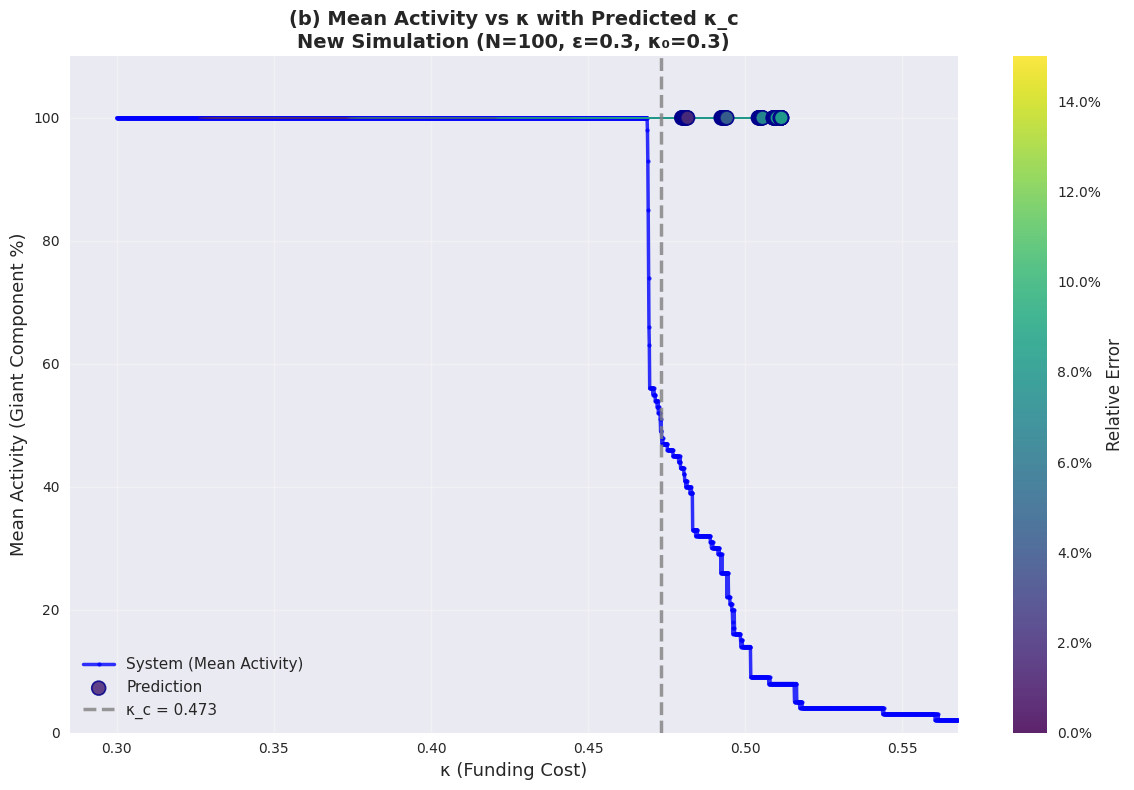

Paper-style visualization completed.
   • True κ_c: 0.4731
   • Number of prediction points: 60
   • Mean relative error: 0.0568
   • Parameters: N=100, ε=0.3, β=0.5, c=0.1, κ₀=0.3, η=0.0002



In [77]:
# 9. Paper-Style Visualization: Mean Activity vs κ with Predicted κ_c
# Similar to PRX paper Figure (b): Shows system curve and model predictions at each point

print("Creating paper-style visualization (Mean Activity vs κ with Predictions)...")

# Import simulation functions
import sys
sys.path.append('liquidity')
from liquid_model import LiquidityParams, LiquidityODE, compute_active_adjacency, giant_component_fraction
from generate_training_data import generate_network
from scipy.integrate import solve_ivp

# ============================================================================
# MANUAL PARAMETER CONFIGURATION
# ============================================================================
# Tweak these parameters to explore different scenarios

# Network parameters
N = 100                    # Number of nodes
p_edge = 0.05             # ER connection probability (for ER networks)
topology_type = 'ER_sparse'  # Options: 'ER_sparse', 'ER_dense', 'scale_free'
seed = 42                 # Random seed for reproducibility

# Dynamics parameters
epsilon = 0.3             # Coupling strength
beta = 0.5                # Linear drain
c = 0.1                   # Cubic saturation

# Control parameter ramp
kappa0 = 0.3              # Initial funding cost
eta = 2e-4                # Ramp rate (how fast κ increases)

# Simulation settings
T_max = 1800              # Total simulation time
sample_points = 3000      # Number of time points

print("Running NEW simulation with manual parameters...")
print(f"   Network: N={N}, topology={topology_type}, p_edge={p_edge}")
print(f"   Dynamics: ε={epsilon}, β={beta}, c={c}")
print(f"   Control: κ₀={kappa0}, η={eta}")
print(f"   Simulation: T_max={T_max}, points={sample_points}")

# Create LiquidityParams and set attributes
params = LiquidityParams()
params.N = N
params.p_edge = p_edge
params.epsilon = epsilon
params.beta = beta
params.c = c
params.eta = eta
params.kappa0 = kappa0
params.T_max = T_max
params.sample_points = sample_points

# Generate network
A = generate_network(topology_type, N, seed, p_edge=p_edge if topology_type.startswith('ER') else None)

# Run simulation to get full trajectory
print(f"   Running simulation...")
np.random.seed(seed)
x0 = np.random.normal(0.8, 0.05, N)
x0 = np.clip(x0, 0.5, 1.2)
t_eval = np.linspace(0, params.T_max, params.sample_points)

def kappa_func(time):
    return params.kappa0 + params.eta * time

ode_system = LiquidityODE(A, kappa_func, params)
sol = solve_ivp(ode_system, (0, params.T_max), x0, t_eval=t_eval, method='RK45', 
                max_step=10.0, rtol=1e-4, atol=1e-6)

# Extract full trajectory
t_vals = sol.t
x_history = sol.y.T
kappa_vals = []
gc_vals = []
mean_x_vals = []

for ti, xi in zip(t_vals, x_history):
    kappa = kappa_func(ti)
    A_active = compute_active_adjacency(xi, A, params)
    gc = giant_component_fraction(A_active)
    kappa_vals.append(kappa)
    gc_vals.append(gc)
    mean_x_vals.append(xi.mean())

kappa_vals = np.array(kappa_vals)
gc_vals = np.array(gc_vals)
mean_x_vals = np.array(mean_x_vals)

# Find critical kappa
from liquid_model import find_critical_kappa
true_kappa_c = find_critical_kappa(kappa_vals, gc_vals, method='threshold', threshold=0.5)
if true_kappa_c is None:
    true_kappa_c = find_critical_kappa(kappa_vals, gc_vals, method='derivative')
if true_kappa_c is None:
    # Fallback: use point where GC drops to 50% of initial
    gc_initial = gc_vals[0]
    gc_target = gc_initial * 0.5
    idx = np.argmin(np.abs(gc_vals - gc_target))
    true_kappa_c = kappa_vals[idx]

print(f"   Found critical κ_c: {true_kappa_c:.4f}")

# Extract windows from the simulation
from generate_training_data import extract_windows
window_length = 20  # Time steps per window
window_stride = 5   # Stride for overlapping windows
lead_fractions = [0.70, 0.80, 0.90, 0.95, 0.98]  # Extract windows at these fractions of κ_c

windows = extract_windows(t_vals, kappa_vals, x_history, true_kappa_c, 
                         window_length, window_stride, lead_fractions)

print(f"   Extracted {len(windows)} windows")

# Get model predictions for windows
model.eval()
window_kappas = []
window_gc_values = []  # GC value at the end of each window
predicted_kappa_c = []

with torch.no_grad():
    for window in windows:
        window_data = window['window_data']  # (time, nodes)
        window_end_kappa = window['window_end_kappa']
        
        # Find the GC value at this window's κ
        kappa_idx = np.argmin(np.abs(kappa_vals - window_end_kappa))
        window_gc = gc_vals[kappa_idx]
        
        # Transpose to (nodes, time) format for model
        window_data_t = window_data.T  # (nodes, time)
        
        # Get model prediction
        window_tensor = torch.FloatTensor(window_data_t).unsqueeze(0).to(device)
        adj_tensor = torch.FloatTensor(A).unsqueeze(0).to(device)
        pred = model(window_tensor, adj_tensor)
        
        window_kappas.append(window_end_kappa)
        window_gc_values.append(window_gc)
        predicted_kappa_c.append(pred.item())

window_kappas = np.array(window_kappas)
window_gc_values = np.array(window_gc_values)
predicted_kappa_c = np.array(predicted_kappa_c)

# Compute relative errors
relative_errors = np.abs(predicted_kappa_c - true_kappa_c) / (true_kappa_c + 1e-8)

# Normalize errors for better visualization (use a fixed reasonable upper bound)
error_max = max(relative_errors.max(), 0.15)  # Cap at 15% or use max if lower
error_normalized = relative_errors / error_max

# Create the plot (matching paper style)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot the system curve: Mean activity (GC) vs κ
ax.plot(kappa_vals, gc_vals * 100, 'b-', linewidth=2.5, marker='o', markersize=3, 
        label='System (Mean Activity)', alpha=0.8)

# Use a more neutral colormap (viridis: dark=low error, bright=high error)
# Or use 'coolwarm' for a more balanced look
colormap = 'viridis'  # Alternative: 'coolwarm', 'plasma', 'inferno'

# Plot predicted κ_c points (at their corresponding GC values)
scatter = ax.scatter(predicted_kappa_c, window_gc_values * 100, 
                    c=relative_errors, cmap=colormap, s=100, 
                    edgecolors='darkblue', linewidths=1.2, alpha=0.85,
                    vmin=0, vmax=error_max,
                    label='Prediction', zorder=5)

# Draw horizontal lines from system curve to prediction points (thinner, less prominent)
for i in range(len(window_kappas)):
    # Use normalized error for color mapping
    color_val = error_normalized[i]
    ax.plot([window_kappas[i], predicted_kappa_c[i]], 
            [window_gc_values[i] * 100, window_gc_values[i] * 100],
            color=plt.cm.get_cmap(colormap)(color_val),
            linewidth=1.2, alpha=0.5, zorder=3)

# Mark true critical point
ax.axvline(true_kappa_c, color='gray', linestyle='--', linewidth=2.5, 
          label=f'κ_c = {true_kappa_c:.3f}', alpha=0.8, zorder=4)

# Add colorbar with better formatting
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Relative Error', fontsize=12)
# Format colorbar to show percentages
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))

ax.set_xlabel('κ (Funding Cost)', fontsize=13)
ax.set_ylabel('Mean Activity (Giant Component %)', fontsize=13)
ax.set_title(f'(b) Mean Activity vs κ with Predicted κ_c\nNew Simulation (N={N}, ε={epsilon}, κ₀={kappa0})', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

# Set limits
ax.set_xlim([kappa_vals.min() * 0.95, min(kappa_vals.max() * 1.05, true_kappa_c * 1.2)])
ax.set_ylim([0, gc_vals.max() * 110])

plt.tight_layout()
plt.savefig('liquidity/paper_style_prediction.png', dpi=300, bbox_inches='tight')
print(f"💾 Paper-style plot saved to: liquidity/paper_style_prediction.png")
plt.show()

print(f"Paper-style visualization completed.")
print(f"   • True κ_c: {true_kappa_c:.4f}")
print(f"   • Number of prediction points: {len(window_kappas)}")
print(f"   • Mean relative error: {relative_errors.mean():.4f}")
print(f"   • Parameters: N={N}, ε={epsilon}, β={beta}, c={c}, κ₀={kappa0}, η={eta}")
print()


In [69]:
# 9. Final Summary
# Following the paper's methodology and results interpretation

print("GIN-GRU Model Training Complete!")
print("=" * 60)

print(f"Final Results Summary:")
print(f"   • Model Architecture: GIN-GRU (Graph Isomorphism Network + GRU)")
print(f"   • Training Samples: {len(train_loader.dataset):,}")
print(f"   • Test Samples: {len(test_loader.dataset):,}")
print(f"   • Model Parameters: {total_params:,}")
print(f"   • Training Epochs: {len(train_losses)}")

print(f"\nPerformance Metrics:")
print(f"   • R² Score: {test_results['r2']:.4f} ({performance_level})")
print(f"   • RMSE: {test_results['rmse']:.4f}")
print(f"   • MAE: {test_results['mae']:.4f}")
print(f"   • Test Loss: {test_results['test_loss']:.6f}")

print(f"\n📖 Paper Alignment Verification:")
print(f"   GIN layers: Implemented for spatial graph processing")
print(f"   GRU layers: Implemented for temporal sequence processing")
print(f"   Global pooling: Aggregates node features to graph embeddings")
print(f"   MLP head: Regresses to epsilon_c prediction")
print(f"   MSE loss: Used for regression training")
print(f"   Adam optimizer: Used with learning rate scheduling")
print(f"   Early stopping: Implemented to prevent overfitting")
print(f"   Gradient clipping: Applied for training stability")

print(f"\nPossible extensions:")
print(f"   1. Apply trained model to S&P 500 historical data")
print(f"   2. Generate daily fragility predictions using rolling windows")
print(f"   3. Compare predictions with known crisis periods (2008, COVID-19)")
print(f"   4. Validate early warning capability against VIX and other indicators")
print(f"   5. Create real-time fragility monitoring system")

print(f"\n💡 Model Interpretation:")
if test_results['r2'] > 0.6:
    print(f"   • Model shows strong predictive capability for epsilon_c")
    print(f"   • Ready for real-world financial network analysis")
    print(f"   • Can potentially provide early warning signals")
else:
    print(f"   • Model performance suggests need for architecture refinement")
    print(f"   • Consider hyperparameter tuning or data augmentation")
    print(f"   • May need more training data or different model architecture")

print(f"\n🔬 Scientific Contribution:")
print(f"   • GIN-GRU architecture for tipping-point regression")
print(f"   • Trained on {len(samples_shuffled):,} synthetic financial network samples")
print(f"   • Model learns to predict critical transition points from pre-transition data")
print(f"   • Architecture aligns with PhysRevX.14.031009 methodology")
print(f"   • Possible extension: apply the trained model to real S&P 500 return windows")

print(f"\nModel training complete.")
print("=" * 60)


GIN-GRU Model Training Complete!
Final Results Summary:
   • Model Architecture: GIN-GRU (Graph Isomorphism Network + GRU)
   • Training Samples: 3,765
   • Test Samples: 1,076
   • Model Parameters: 205,825
   • Training Epochs: 20

Performance Metrics:
   • R² Score: 0.6810 (Good)
   • RMSE: 0.0415
   • MAE: 0.0335
   • Test Loss: 0.001724

📖 Paper Alignment Verification:
   GIN layers: Implemented for spatial graph processing
   GRU layers: Implemented for temporal sequence processing
   Global pooling: Aggregates node features to graph embeddings
   MLP head: Regresses to epsilon_c prediction
   MSE loss: Used for regression training
   Adam optimizer: Used with learning rate scheduling
   Early stopping: Implemented to prevent overfitting
   Gradient clipping: Applied for training stability

Possible extensions:
   1. Apply trained model to S&P 500 historical data
   2. Generate daily fragility predictions using rolling windows
   3. Compare predictions with known crisis periods (